In [2]:
# ----------------------------------------------------------------------------
# Title: Assignment 1.2
# Author: Surenther Selvaraj
# Date: 04 Dec 2025
# Modified By: Surenther Selvaraj
# Description: R/Python Refresher
# Data: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis 
# ----------------------------------------------------------------------------

## Overview of the Data
A fictional marketing firm supplies the Customer Personality Analysis dataset and is commonly used to study customer groups and design targeted marketing strategies. By examining the information in this file, the company can gain a deeper understanding of its customers, their shopping habits, and how they typically respond to promotional offers.

The dataset comprises approximately 2,240 entries and 29 variables, which describe various customer traits and behaviors. 

The variables can be organized into 4 key areas:
| Category  | Key Variables  |  Description |
|---|---|---|
| People/Demographics | ID, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome | Personal traits and information about the customer's household |
| Products/Spending | MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds | The amount of money spent on different product types over the last two years.|
| Promotion/Campaigns | AcceptedCmp1 - AcceptedCmp5, Response (last campaign acceptance), NumDealsPurchases, Complain | Customer responses to five previous marketing campaigns and whether they accepted the most recent one.|

## Preparing the Data
A few cleanup and transformation steps are needed before creating visuals:
* Missing Income Values: Any gaps in the Income field should be handled; using the median Income is a practical choice that maintains dataset consistency.
* Adding an Age Feature: Age can be computed by subtracting Year_Birth from the current year.
* Combining Spending Columns: A new column, TotalSpending, can be created by summing all the “Mnt” (money spent) fields. This gives a single indicator of how much each customer typically spends.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#1. Load Data
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 2. Handle Income missing values (e.g., impute with the mean or median)
median_income = df['Income'].median() # Calculate median income
df['Income'] = df['Income'].fillna(median_income) # Fill NA values with median income

# 3. Create 'Age' variable
current_year = datetime.now().year # Get the current year
df['Age'] = current_year - df['Year_Birth'] # Calculate age

# 4. Create 'TotalSpending' variable
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'] # List of spending columns
df['TotalSpending'] = df[mnt_cols].sum(axis=1) # Sum spending columns to create TotalSpending 

# 5. Display first few rows of the modified DataFrame
print(df.head(5))

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp4  AcceptedCmp5  \
0  04-09-2012       58       635  ...             0             0   
1  08-03-2014       38        11  ...             0             0   
2  21-08-2013       26       426  ...             0             0   
3  10-02-2014       26        11  ...             0             0   
4  19-01-2014       94       173  ...             0             0   

   AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  \
0             0             0        

## Visual Exploration Ideas
Since the dataset is centered on customer behavior, the following questions work well for visual analysis:

### Question 1: How does Income relate to Total Spending?
This relationship helps show whether customers with higher incomes are also the ones spending more on the company’s products. The pattern can reveal valuable clusters, such as groups that consistently spend above or below what their income level might suggest.

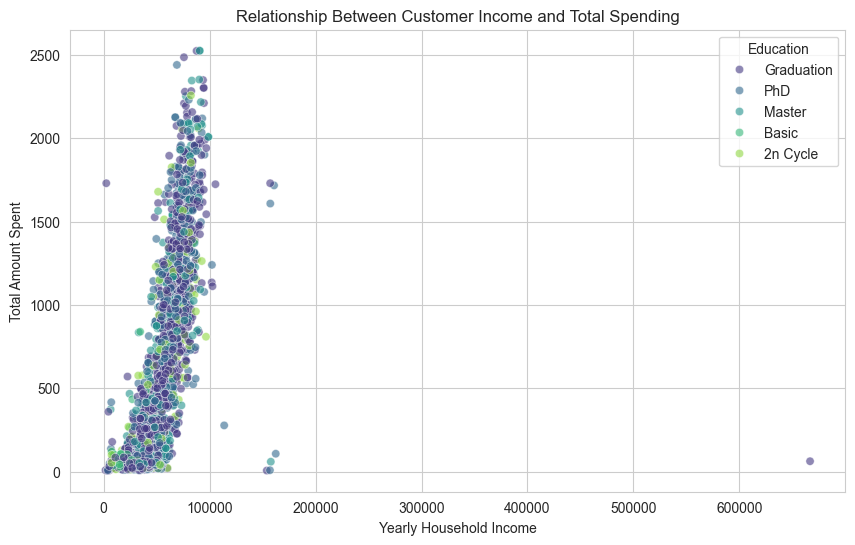

In [4]:
# Set visualization style
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# Use a scatter plot, coloring by Education level for richer insight
sns.scatterplot(
    data=df,
    x='Income',
    y='TotalSpending',
    hue='Education',  # Group points by education
    alpha=0.6,
    palette='viridis'
 )

plt.title('Relationship Between Customer Income and Total Spending')
plt.xlabel('Yearly Household Income')
plt.ylabel('Total Amount Spent')
plt.show()

### Observation

* The scatter plot primarily shows a strong positive correlation between customer Yearly Household Income and Total Amount Spent, with a concentration below $100,000.
* The vast majority of customers have incomes under $100,000 and spend less than $2,500 over the two years.
* There is a dense vertical cluster of points near the high end of spending (around $1,500 to $2,500) for incomes ranging from about $50,000 to $90,000.
* The dataset contains a few significant outliers, including two customers with extremely high incomes (over $600,000) who exhibit extremely low spending, which challenges the overall positive trend.
* Customers across all Educational levels (especially those at the Graduate, PhD, and Master's Levels) are well-represented within the core high-spending group.

### Question 2: Which Education or Marital Status groups responded best to the latest marketing campaign?
Understanding which segments were most likely to respond (Response = 1) can steer future targeting decisions. It’s helpful in determining where marketing efforts are likely to yield results.

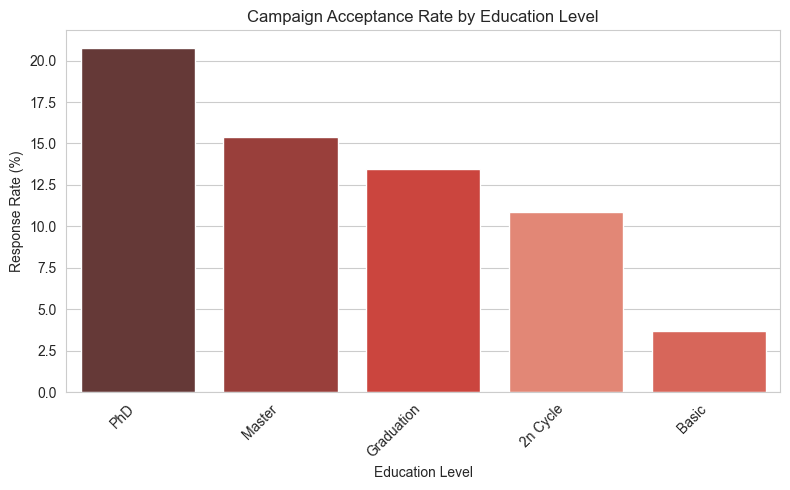

In [5]:
# 1. Calculate the conversion rate (mean of 'Response') for each Education level
education_conversion = df.groupby('Education')['Response'].mean().reset_index()
education_conversion['Response_Rate'] = education_conversion['Response'] * 100

# 2. Plot the results
plt.figure(figsize=(8, 5))
sns.barplot(
    data=education_conversion,
    x='Education',
    y='Response_Rate',
    hue='Education', 
    palette='Reds_d',
    order=education_conversion.sort_values('Response_Rate', ascending=False)['Education'],
    legend=False  
)

plt.title('Campaign Acceptance Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation
* The graph clearly shows that customers with PhD degrees have the highest campaign acceptance rate at just over 20%.
* Following closely are customers with Master's degrees (around 15%) and Graduation degrees (about 13.5%).
* The acceptance rate generally declines as the level of education decreases.
* Customers with a 2n Cycle education level show a moderate acceptance rate, slightly above 10%.
* Customers with a Basic education level are the least responsive to the campaign, with an acceptance rate of less than 5%.

### Question 3: What’s the marital status composition of our customer base?
By showing the count of customers in each category, the bar chart offers a straightforward look at the demographic landscape and highlights notable differences between the groups.

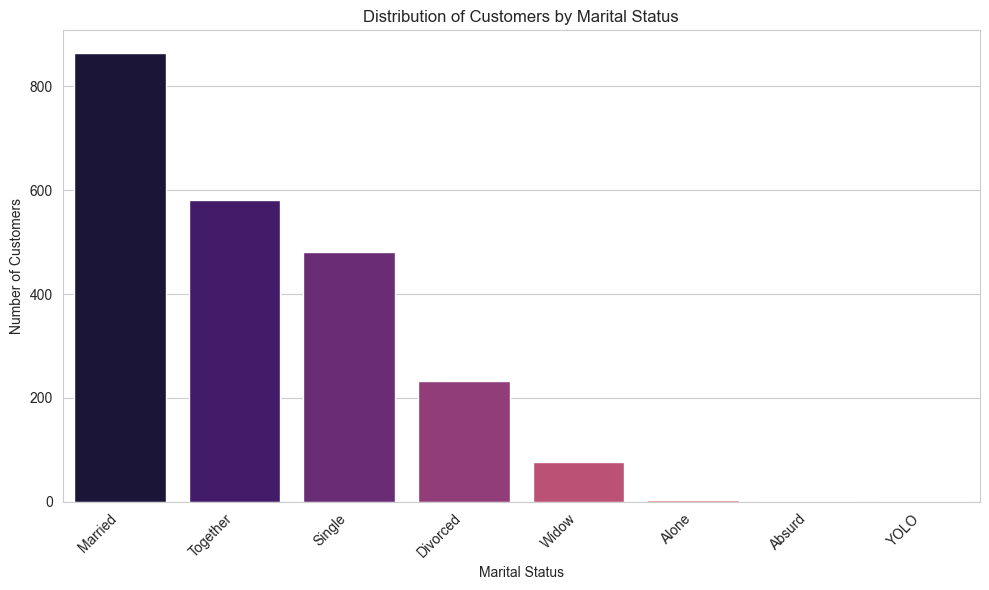

In [9]:
# 1. Calculate the counts for each 'Marital_Status' category
marital_counts = df['Marital_Status'].value_counts().reset_index()
marital_counts.columns = ['Marital_Status', 'Count']

# 2. Set up the visualization style
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# 3. Create the bar plot
sns.barplot(
    data=marital_counts,
    x='Marital_Status',
    y='Count',
    hue='Marital_Status', 
    palette='magma',
    order=marital_counts['Marital_Status'],
    legend=False      
)

plt.title('Distribution of Customers by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

* The largest customer segment is Married, accounting for approximately 850 customers, making it the dominant segment.
* The following two major segments are Together (around 580 customers) and Single (around 480 customers), representing significant portions of the base.
* The majority of customers are either married or in a relationship, which combined represents well over half of the total population.
* The divorced and Widowed statuses comprise the smaller, but still substantial, secondary groups, totaling over 300 customers combined.
* Categories like Alone, Absurd, and YOLO are extremely rare outliers, each having a count close to zero.

### Question 4: How is Total Spending distributed across different Education Levels? 
A boxplot helps illustrate how Total Spending differs between education groups by showing the median, the spread of values, and any skew in the data. 
It makes it easier to identify which groups tend to spend the most on average, which ones exhibit more consistent spending patterns, and where any unusually high spending values are located.

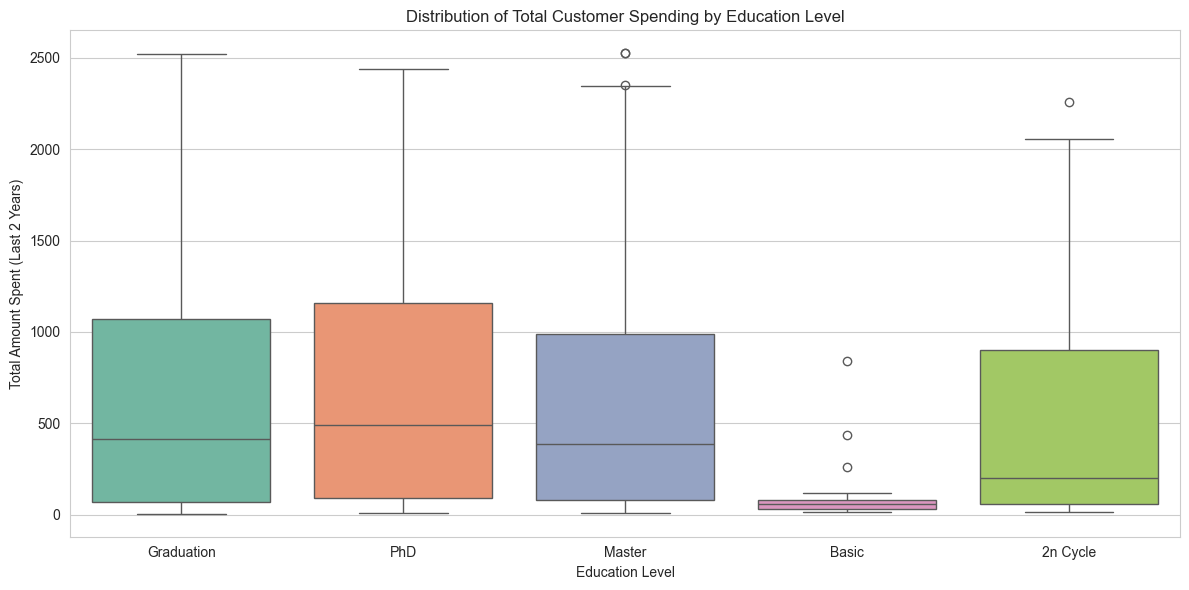

In [ ]:
# 1. Set up the visualization style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# 2. Create the box plot
sns.boxplot(
    data=df,
    x='Education',
    y='TotalSpending',
    hue='Education',
    palette='Set2'
)

plt.title('Distribution of Total Customer Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Total Amount Spent (Last 2 Years)')
plt.tight_layout()
plt.show()

### Observation
* The highest median spending is attributed to the PhD group (approximately $500), closely followed by the Graduation and Master groups.
* The Basic education level shows the lowest median spending, clustering near zero, indicating minimal engagement or low-value purchases for the typical customer in this segment.
* All higher education groups (Graduation, PhD, Master's, 2n Cycle) show a wide spread in spending, with their 75th percentiles extending close to $ 1,000.
* The PhD and Master groups exhibit the most significant outliers in high-end spending, with some customers spending over $2,000 and $2,500.
* The 2n Cycle group has a highly skewed distribution, characterized by a low median but a vast range, indicating that while most customers spend little, some are high-value purchasers.

### Question 5: How does a customer’s Marital Status affect their Campaign Acceptance Rate for the latest campaign?
This question employs a bivariate approach to compare two nominal (categorical) variables: Marital_Status and the successful campaign response (Response = 1). 
A Grouped Bar Chart is ideal for this, allowing us to simultaneously visualize the acceptance rate for all five campaigns across different marital groups.

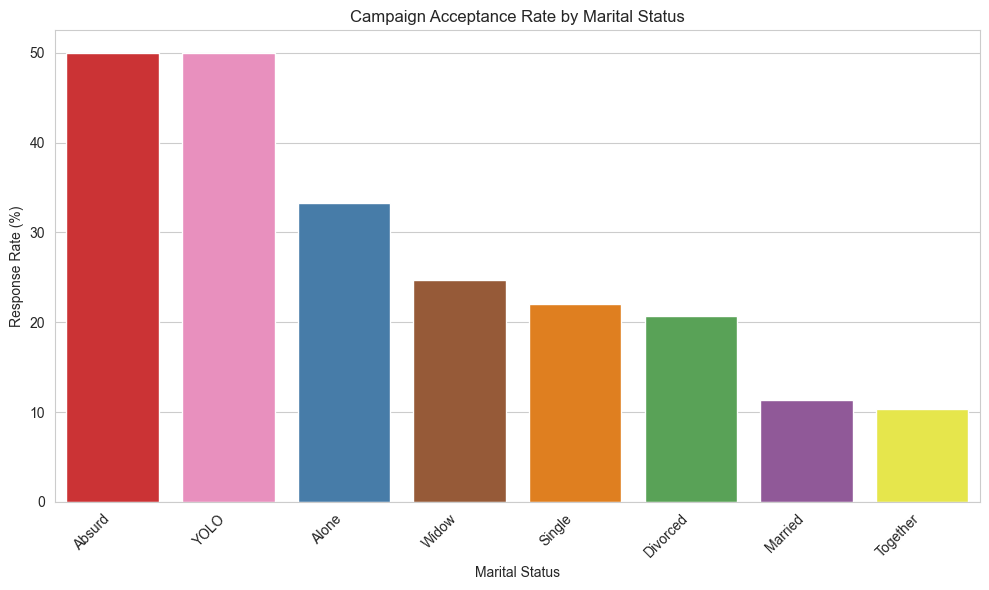

In [13]:
# 1. Calculate the conversion rate (mean of 'Response') for each Marital Status
status_conversion = df.groupby('Marital_Status')['Response'].mean().reset_index()
status_conversion['Response_Rate'] = status_conversion['Response'] * 100

# 2. Set up the visualization style
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# 3. Create the Bar Plot (Bivariate analysis: Status vs. Acceptance Rate)
sns.barplot(
    data=status_conversion,
    x='Marital_Status',
    y='Response_Rate',
    hue='Marital_Status', # Explicitly set hue
    palette='Set1',
    order=status_conversion.sort_values('Response_Rate', ascending=False)['Marital_Status'],
    legend=False
)

plt.title('Campaign Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation
* The highest campaign acceptance rates belong to the extremely small, outlier groups of Absurd and YOLO, both showing a 50% response rate.
* The next most responsive segment is the Alone status, with an acceptance rate of about 34%.
* Among the major status groups, Widow and Single are the most responsive, with rates around 24% and 22% respectively.
* Customers who are Divorced show a moderate response rate of about 20%.
* The two largest customer segments, Married and Together, show the lowest acceptance rates at approximately 11% and 10% respectively, suggesting low conversion efficiency for these large groups.

## Summary of Results and Conclusion
### Key Findings from Visual Analysis
| Question  | Visualization  |  Key Finding |
|---|---|---|
|Q1: Income vs. Spending|Scatter Plot|A strong positive correlation exists between Income and Total Spending, but only up to an income of about $100,000. Beyond this point, spending plateaus or becomes highly unpredictable (outliers).|
|Q2: Campaign Acceptance by Education|Bar Chart|PhD and Master's degree holders are the most responsive to the campaign (20%+ acceptance), while the Basic education group is the least responsive (under 5%).|
|Q3: Marital Status Distribution|Bar Chart|The customer base is heavily concentrated in the Married and Together groups (the majority of all customers).|
|Q4: Spending by Education|Box Plot|Higher education groups (PhD, Graduation, Master's) have significantly higher median total spending and a greater number of high-value outliers (spending 2,000+).|
|Q5: Campaign Acceptance by Marital Status|Bar Chart|The largest segments (Married/Together) are the least responsive (around 10-11% acceptance), while the smaller groups (Widow/Single) are substantially more responsive (22-24%).|


### Conclusion: 
The company's highest potential for ROI (Return on Investment) from its marketing campaigns lies in targeting customers who have high incomes and high educational attainment, particularly those with PhD, Master's degrees, or Graduation degrees. Conversely, the most significant demographic segments (Married/Together) are the least efficient to target.

### Supporting Evidence from Visualizations
The visualizations systematically support this conclusion by isolating two distinct market profiles:
* The High-Value Spender Profile (Supported by Q1 and Q4)
    * Q1 (Scatter Plot): This plot shows that spending potential is directly tied to income up to a certain threshold. High spenders (those above $1,000) almost universally fall into the $50,000 to $100,000 income bracket, demonstrating that income is a necessary factor.
    * Q4 (Box Plot): This visualization adds the crucial second factor: education. It clearly indicates that the highest median spending and the most extreme high-spending outliers are concentrated in the PhD, Master's, and Graduation groups.
        * Support: The boxplots for these three groups show the highest median lines and the largest interquartile range (IQR), confirming that while income creates the potential, higher education correlates with the actual high spending.
* The Low-Efficiency (or High-Conversion) Profile (Supported by Q2, Q3, and Q5)
    * Q3 (Marital Status Distribution): This chart establishes that the Married and Together segments constitute the majority of the customer base.
    * Q5 (Campaign Acceptance by Marital Status): This bar chart shows that the two largest segments (Married/Together) have the lowest acceptance rates (around 10%), meaning a large portion of the marketing effort currently targets a low-converting audience.
    * Q2 (Campaign Acceptance by Education): This chart confirms that acceptance is strongly tied to education level, with PhD being the most receptive group overall.

In short, the analysis suggests the most profitable customer is likely a PhD or Master's degree holder earning between $50,000 and $100,000. Although the Married and Together groups are the largest, they are the least likely to convert as a result of a marketing campaign.